# Red neuronal para reconocimiento de nÃƒÂºmeros


# Importacion de librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## Carga del dataset

El dataset MNIST se carga directamente desde TensorFlow. Este dataset contiene imagenes de digitos escritos a mano, con etiquetas del 0 al 9.


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

## Visualizacion de algunos datos

Antes de entrenar la red neuronal, se muestran algunas imagenes del dataset para ver como son los numeros escritos a mano.


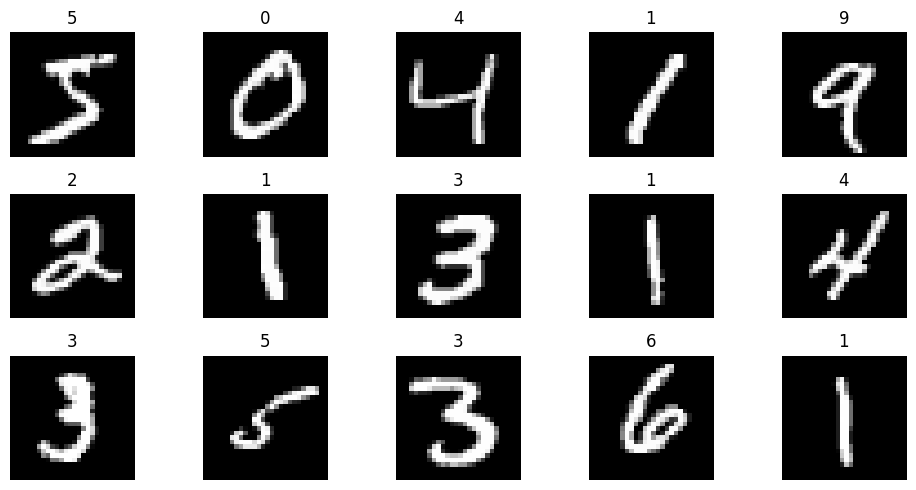

In [5]:
plt.figure(figsize=(10, 5))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


## Cantidad de datos por clase

Se revisa cuantas imagenes hay para cada numero. Para verificar que el dataset esta balanceado.


In [6]:
pd.Series(y_train).value_counts().sort_index()


0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

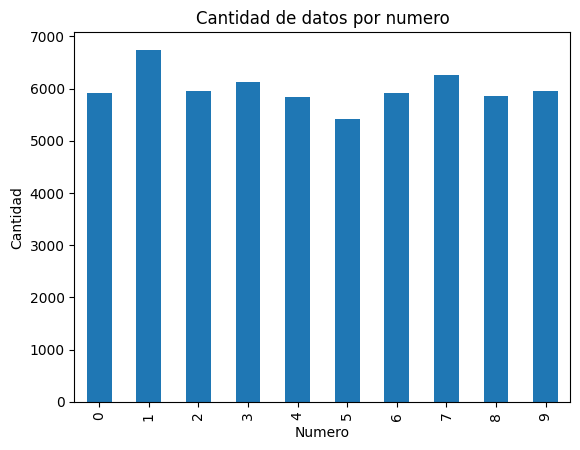

In [7]:
pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
plt.title("Cantidad de datos por numero")
plt.xlabel("Numero")
plt.ylabel("Cantidad")
plt.show()


## Preprocesamiento de datos

Las imagenes tienen pixeles con valores entre 0 y 255. Para que la red neuronal trabaje mejor, se dividen esos valores para 255 y asi quedan en un rango entre 0 y 1.


In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0


In [9]:
print(x_train.min())
print(x_train.max())
print(x_train.shape)
print(x_test.shape)


0.0
1.0
(60000, 28, 28)
(10000, 28, 28)


## Construccion del modelo

Se crea una red neuronal secuencial. Primero se usa `Flatten` para convertir cada imagen de 28x28 en un vector. Luego se agregan tres capas ocultas con activacion `relu`, y al final una capa de salida con 10 neuronas porque hay 10 posibles numeros.


In [10]:
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])



In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compilacion del modelo

Se compila el modelo indicando el optimizador, la funcion de perdida y la metrica que se va a observar. Como se tienen 10 clases y las etiquetas estan como numeros enteros, se usa `sparse_categorical_crossentropy`.


In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## Entrenamiento

Se entrena el modelo con los datos de entrenamiento. Tambien se separa una parte de esos datos para validacion, asi se puede observar como se comporta la red con datos que no usa directamente para ajustar los pesos.


In [13]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)


Epoch 1/10
422/422 - 5s - 13ms/step - accuracy: 0.9097 - loss: 0.3184 - val_accuracy: 0.9625 - val_loss: 0.1316
Epoch 2/10
422/422 - 3s - 7ms/step - accuracy: 0.9624 - loss: 0.1252 - val_accuracy: 0.9713 - val_loss: 0.1039
Epoch 3/10
422/422 - 3s - 7ms/step - accuracy: 0.9743 - loss: 0.0834 - val_accuracy: 0.9747 - val_loss: 0.0872
Epoch 4/10
422/422 - 4s - 8ms/step - accuracy: 0.9798 - loss: 0.0625 - val_accuracy: 0.9727 - val_loss: 0.0958
Epoch 5/10
422/422 - 3s - 7ms/step - accuracy: 0.9847 - loss: 0.0485 - val_accuracy: 0.9778 - val_loss: 0.0802
Epoch 6/10
422/422 - 3s - 6ms/step - accuracy: 0.9871 - loss: 0.0407 - val_accuracy: 0.9717 - val_loss: 0.0970
Epoch 7/10
422/422 - 3s - 6ms/step - accuracy: 0.9904 - loss: 0.0311 - val_accuracy: 0.9783 - val_loss: 0.0873
Epoch 8/10
422/422 - 2s - 5ms/step - accuracy: 0.9908 - loss: 0.0278 - val_accuracy: 0.9775 - val_loss: 0.0880
Epoch 9/10
422/422 - 2s - 5ms/step - accuracy: 0.9926 - loss: 0.0217 - val_accuracy: 0.9775 - val_loss: 0.0963


## Graficas del entrenamiento

Se revisa como cambian la perdida y la precision durante las epocas de entrenamiento.


In [14]:
historial = pd.DataFrame(history.history)
historial


,accuracy,loss,val_accuracy,val_loss
0,0.909685,0.318378,0.962500,0.131616
1,0.962426,0.125201,0.971333,0.103922
2,0.974259,0.083361,0.974667,0.087213
3,0.979833,0.062537,0.972667,0.095776
4,0.984741,0.048531,0.977833,0.080217
5,0.987130,0.040653,0.971667,0.097038
6,0.990352,0.031075,0.978333,0.087269
7,0.990759,0.027809,0.977500,0.087962
8,0.992611,0.021652,0.977500,0.096286
9,0.992241,0.023364,0.975167,0.102594


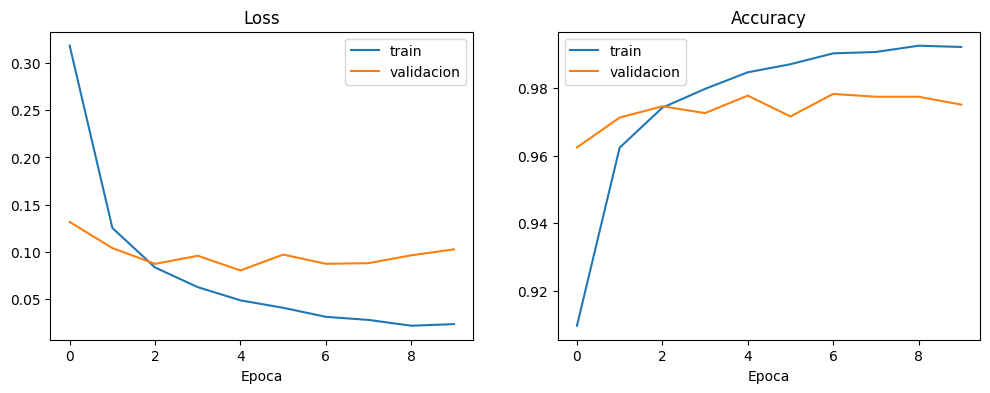

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historial["loss"], label="train")
plt.plot(historial["val_loss"], label="validacion")
plt.title("Loss")
plt.xlabel("Epoca")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial["accuracy"], label="train")
plt.plot(historial["val_accuracy"], label="validacion")
plt.title("Accuracy")
plt.xlabel("Epoca")
plt.legend()

plt.show()


## Evaluacion del modelo

Se evalua el modelo con los datos de entrenamiento y con los datos de prueba. Tambien se compara el error de entrenamiento con el error de prueba, porque si el error de prueba es mucho mayor, puede ser una seÃƒÂ±al de sobreajuste.



In [16]:
train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

error_train = 1 - train_accuracy
error_test = 1 - test_accuracy
diferencia_error = error_test - error_train

print("Accuracy train:", train_accuracy)
print("Accuracy test:", test_accuracy)

print("Error train:", error_train)
print("Error test:", error_test)

print("Diferencia entre error test y error train:", diferencia_error)



Accuracy train: 0.991683304309845
Accuracy test: 0.9775000214576721
Error train: 0.00831669569015503
Error test: 0.02249997854232788
Diferencia entre error test y error train: 0.014183282852172852


## Predicciones

El modelo devuelve una probabilidad para cada una de las 10 clases. Para obtener la prediccion final se usa `argmax`, que selecciona la clase con mayor probabilidad.


In [17]:
train_output = model.predict(x_train)
test_output = model.predict(x_test)

y_train_predic = np.argmax(train_output, axis=1)
y_test_predic = np.argmax(test_output, axis=1)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## Reporte de clasificacion

Se muestra precision, recall y f1-score para cada numero. Esto permite revisar si el modelo funciona bien para todas las clases.

In [18]:
print(classification_report(y_test, y_test_predic))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.98      0.97       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## Matriz de confusion

La matriz de confusion permite observar en que numeros acierta o se equivoca el modelo. Los valores de la diagonal principal representan las predicciones correctas.

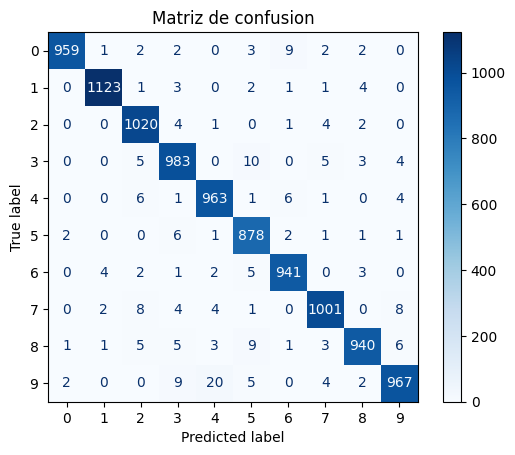

In [19]:
matriz = confusion_matrix(y_test, y_test_predic)

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=np.arange(10)
).plot(cmap="Blues")

plt.title("Matriz de confusion")
plt.show()

### Validacion del modelo

Se toma una imagen del conjunto de prueba para ver que numero predice el modelo y con que probabilidad asigna cada clase del 0 al 9.


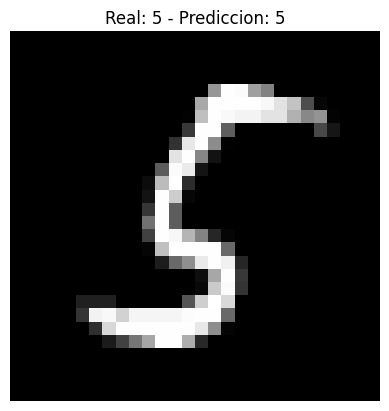

In [20]:
numero = 5

indices = np.where(y_test == numero)[0]
indice = np.random.choice(indices)

probabilidades = test_output[indice]
prediccion = y_test_predic[indice]
real = y_test[indice]

plt.imshow(x_test[indice], cmap="gray")
plt.title(f"Real: {real} - Prediccion: {prediccion}")
plt.axis("off")
plt.show()


In [21]:
tabla_probabilidades = pd.DataFrame({
    "numero": np.arange(10),
    "probabilidad": probabilidades
})

tabla_probabilidades


,numero,probabilidad
0,0,5.994223e-12
1,1,4.353712e-09
2,2,9.973342e-11
3,3,3.290461e-06
4,4,9.893416e-13
5,5,9.999965e-01
6,6,6.437976e-10
7,7,1.476743e-13
8,8,8.806362e-08
9,9,1.708742e-08


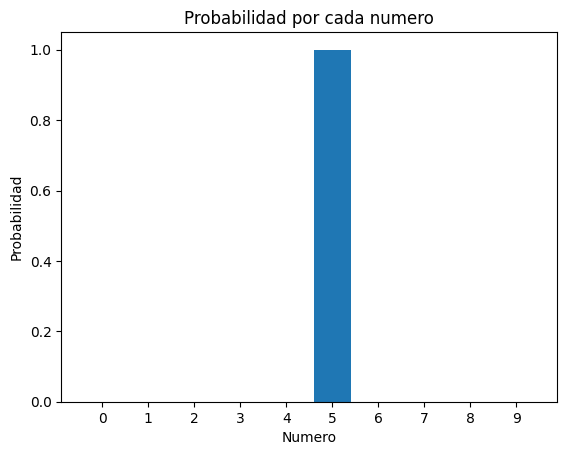

In [22]:
plt.bar(tabla_probabilidades["numero"], tabla_probabilidades["probabilidad"])
plt.xticks(np.arange(10))
plt.title("Probabilidad por cada numero")
plt.xlabel("Numero")
plt.ylabel("Probabilidad")
plt.show()


## Conclusion

El modelo obtuvo un accuracy alto tanto en entrenamiento como en prueba. La diferencia entre el error de prueba y el error de entrenamiento fue pequena, por lo que no se observa un sobreajuste fuerte.

La red neuronal logra reconocer correctamente la mayoria de digitos escritos a mano. Algunos errores pueden aparecer cuando los numeros tienen formas parecidas o cuando la escritura no es clara.